In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter

# GEM-$\alpha$

For the GEM potential defined on $[-L/2,L/2]$ we have that $$W(r) = -e^{-\Big(\frac{\|r\|}{\sqrt{2\sigma^2}}\Big)^\alpha}$$
and therefore taking the Fourier transform we have for $k$ of the form $2\pi z/L$, where $z \in \mathbb{Z}$
$$\hat{W}(k) =   -\int^{L/2}_{-L/2} e^{-\Big(\frac{\|r\|}{\sqrt{2\sigma^2}}\Big)^\alpha}\cos{(2\pi zr/L)}dr . $$

In [3]:
from scipy.special import jv
from scipy.integrate import quad

# to do
L  = 10.
σ = np.sqrt(0.5)
α  = 4.0

#@numba.jit(nopython=True)
def integrand_GEM(r,z):
    #integrate numerically
    des = -np.exp(-(np.abs(r)/np.sqrt(2*(σ**2)))**α)*np.cos(z*r)#De*(np.exp(-2*a*(np.abs(r)-re))-2*np.exp(-a*(np.abs(r)-re)))*np.cos(z*r)
    return des 


def W_hat_GEM(k):
    #integrate numerically
    W_hat_k = quad(integrand_GEM,-L/2,L/2,args = (k,))
    return W_hat_k[0]


def matrix_GEM(k,β,γ,L,dim):
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    for i in range(dim-1):
        A_k[i][i] = i*(-γ) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/β)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/β)*1j 
    A_k[dim-1][dim-1] = (dim-1)*-γ
    A_k[1][0] += -k*np.sqrt(β)*1j*W_hat_GEM(k)/L
    return A_k

In [4]:
# For a number of temperatures and friction values, obtain largest eigenvalues.
def function_params(β,γ):

    k_max = 30  # number of wavenumbers to test.
    
    approximation_dimension = 30  # number of matrix rows to consider.
    maximum = np.max(np.real(np.linalg.eigvals(matrix_GEM(0.,β,γ,L,approximation_dimension))))
    
    # find maximum eigenvalue for all wavenumbers
    for k in range(k_max - 1):
        #change to maximum real part
        partial_max = np.max(np.real(np.linalg.eigvals(matrix_GEM(2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
        #print(partial_max,maximum)
        if partial_max > maximum:
            maximum = partial_max
        partial_max = np.max(np.real(np.linalg.eigvals(matrix_GEM(-2*np.pi*(k+1)/L,β,γ,L,approximation_dimension))))
        #print(partial_max,maximum)
        if partial_max > maximum:
            maximum = partial_max
    spectral_radius = maximum
    
    return spectral_radius
    
def function():
    
    N_β = 1    # Number of temperature points.
    N_γ = 300      # Number of friction points.
    β_list = np.array([25])
    γ_list = np.linspace(0.01,3.0,N_γ) #np.logspace(-8.0, 1.0, num=N_γ)
    
    spectral_radius = np.zeros((N_β,N_γ))  # store largest real part of eigenvalues here.
    
    # for all beta and gamma...
    for i in range(len(β_list)):
        print("beta: ", i)
        β = β_list[i]
        for j in range(len(γ_list)):
            γ = γ_list[j]
            maximum = function_params(β,γ)
            spectral_radius[i,j] = maximum
    
    return β_list,γ_list,spectral_radius



In [5]:
# For all temperatures and frictions, obtain largest eigenvalues.
β_list,γ_list,spectral_radius = function()

beta:  0


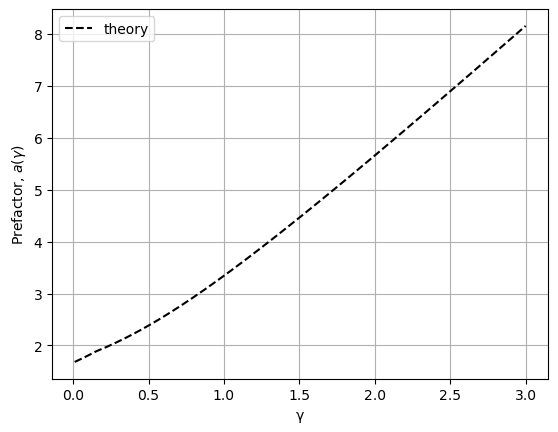

In [6]:
# plot the eigenvalue against beta
#arr = np.loadtxt('a_fit.csv', delimiter=",")
plt.plot(γ_list,1/(2*spectral_radius[0,:]),'--k',label='theory')
plt.grid()
plt.legend()
#plt.xscale('log')
#plt.yscale('log')
#plt.title('γ='+str(γ_list[gamma_idx]))
plt.xlabel('γ')
plt.ylabel('Prefactor, $a(γ)$')
plt.show()

In [7]:
print(spectral_radius)

[[0.29699132 0.29470259 0.29241398 0.2901257  0.28783814 0.28555174
  0.28326695 0.28098425 0.27870414 0.27642714 0.27415379 0.27188466
  0.26962034 0.26736141 0.26530437 0.26364566 0.26198812 0.26033199
  0.25867751 0.25702492 0.2553745  0.2537265  0.25208119 0.25043885
  0.24879974 0.24716417 0.2455324  0.24390473 0.24228145 0.24066283
  0.23904917 0.23744076 0.23583787 0.23424079 0.2326498  0.23106516
  0.22948715 0.22791602 0.22635204 0.22479544 0.22324648 0.22170538
  0.22017237 0.21864768 0.2171315  0.21562404 0.21412549 0.21263604
  0.21115585 0.20968509 0.20822392 0.20677248 0.2053309  0.20389932
  0.20247786 0.20106661 0.1996657  0.19827519 0.19689519 0.19552576
  0.19416697 0.19281889 0.19148156 0.19015503 0.18883934 0.18753451
  0.18624058 0.18495755 0.18368545 0.18242426 0.18117401 0.17993467
  0.17870624 0.17748871 0.17628204 0.17508622 0.17390121 0.17272699
  0.17156351 0.17041073 0.1692686  0.16813709 0.16701613 0.16590567
  0.16480565 0.16371602 0.16263671 0.16156766 0.

In [19]:
np.savetxt("GEM4_theory.csv", 1/(2*spectral_radius), delimiter=",")
np.savetxt("x_theory.csv", γ_list, delimiter=",")
